In [124]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [125]:
#loading data set
df = pd.read_csv('/content/mobiles1.csv')

In [126]:
df.sample()

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty
696,3000 mAh Battery,13MP + 2MP | 16MP Front Camera,14.83 cm (5.84 inches) Display,4 GB RAM | 64 GB ROM | Expandable Upto 256 GB,"Honor 9N (Sapphire Blue, 64 GB)",15999,Kirin 659 Octa Core Processor,4.3,"21,349 Reviews","12 Months on handset, 6 Months on battery , 6 ..."


In [127]:
df.shape

(984, 10)

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   battery    984 non-null    object 
 1   camera     984 non-null    object 
 2   display    984 non-null    object 
 3   memory     984 non-null    object 
 4   name       984 non-null    object 
 5   price      984 non-null    int64  
 6   processor  983 non-null    object 
 7   rating     971 non-null    float64
 8   reviews    971 non-null    object 
 9   warranty   836 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 77.0+ KB


In [129]:
df.isnull().sum()

,0
battery,0
camera,0
display,0
memory,0
name,0
price,0
processor,1
rating,13
reviews,13
warranty,148


In [130]:
df.describe()

,price,rating
count,984.000000,971.000000
mean,15429.848577,4.241195
std,12891.355967,0.300296
min,887.000000,2.700000
25%,7499.000000,4.100000
50%,11649.000000,4.300000
75%,17999.250000,4.400000
max,104999.000000,4.900000


In [131]:
df.sample(5)

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty
762,3600 mAh Battery,8MP + 8MP | 8MP Front Camera,13.97 cm (5.5 inch) Full HD Display,3 GB RAM | 32 GB ROM | Expandable Upto 128 GB,"Honor 6 Plus (Black, 32 GB)",26499,Hisilicon Kirin 925 Cortex-A15 + Cortex-A7 Pro...,3.9,169 Reviews,"12 Months on handset, 6 Months on battery , 6 ..."
272,2600 mAh Lithium-ion Battery,8MP Rear Camera | 5MP Front Camera,12.7 cm (5 inch) quarter HD Display,1 GB RAM | 16 GB ROM | Expandable Upto 256 GB,"Samsung Galaxy J2 Core (Black, 16 GB)",6299,Qualcomm MSM8917 Processor,4.2,731 Reviews,1 Year Manufacturer Warranty for Phone and 6 M...
268,4315 mAh Lithium-ion Battery,48MP + 13MP + 8MP + 8MP | 32MP Front Camera,16.66 cm (6.56 inch) Full HD+ E3 Super AMOLED ...,8 GB RAM | 256 GB ROM,"Vivo X50 Pro (Alpha Grey, 256 GB)",49990,Qualcomm Snapdragon 765G Processor,4.4,64 Reviews,5G Phone
491,4000 mAh Lithium-ion Battery,48MP + 12MP + 5MP + 5MP | 32MP Front Camera,16.26 cm (6.4 inch) Full HD+ Display,6 GB RAM | 128 GB ROM | Expandable Upto 512 GB,"Samsung Galaxy A51 (Prism Crush White, 128 GB)",23999,Exynos 9611 Processor,4.4,565 Reviews,Brand Warranty of 1 Year Available for Mobile ...
512,3000 mAh Li-ion Battery,13MP Rear Camera | 5MP Front Camera,12.7 cm (5 inch) HD Display,2 GB RAM | 16 GB ROM,"VOTO V11 (Black, 16 GB)",3690,Spreadtrum 9832 Processor,3.5,16 Reviews,Brand Warranty of 1 Year Available for Mobile ...


In [132]:
df = df.drop_duplicates()

In [133]:
df.shape

(960, 10)

In [134]:
df = pd.read_csv('/content/mobiles1.csv')
df[df['processor'].isna()]

,battery,camera,display,memory,name,price,processor,rating,reviews,warranty
825,5000 mAh Battery,16MP Rear Camera,16.59 cm (6.53 inch) Display,6 GB RAM | 64 GB ROM,"Vivo U20 (Racing Black, 64 GB)",11998,NaN,4.1,33 Reviews,NaN


In [135]:
df = df.drop(columns=['warranty'])

In [144]:
df['rating'] = df['rating'].fillna(df['rating'].mean())


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   battery           984 non-null    object  
 1   camera            984 non-null    object  
 2   display           984 non-null    object  
 3   memory            984 non-null    object  
 4   name              984 non-null    object  
 5   price             984 non-null    int64   
 6   processor         983 non-null    object  
 7   rating            984 non-null    float64 
 8   reviews           971 non-null    object  
 9   battery_capacity  984 non-null    int16   
 10  company_name      984 non-null    category
dtypes: category(1), float64(1), int16(1), int64(1), object(7)
memory usage: 74.7+ KB


In [146]:
df['battery_capacity'] = df['battery'].str.split().str[0].astype('int16')

In [169]:
df['company_name'] = df['name'].str.split().str[0].astype('category')
df['reviews_count'] = df['reviews'].str.replace(',', '', regex=False).str.split().str[0]
df['reviews_count'] = pd.to_numeric(df['reviews_count'], errors='coerce')
df['reviews_count'] = df['reviews_count'].fillna(0).astype('int64')

In [170]:
df['reviews_count'] = df['reviews_count'].fillna(df['reviews_count'].mean())

In [171]:
df.head()

,battery,camera,display,memory,name,price,processor,rating,reviews,battery_capacity,company_name,reviews_count
0,5000 mAh Battery,12MP + 2MP | 8MP Front Camera,15.8 cm (6.22 inch) HD+ Display,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB,"Redmi 8 (Ruby Red, 64 GB)",9999,Qualcomm Snapdragon 439 Processor,4.4,"55,078",5000,Redmi,55078
1,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 64 GB ROM,"Realme 5i (Aqua Blue, 64 GB)",10999,Qualcomm Snapdragon 665 2 GHz Processor,4.5,"20,062",5000,Realme,20062
2,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Aqua Blue, 128 GB)",11999,Qualcomm Snapdragon 665 (2 GHz) Processor,4.5,"20,062",5000,Realme,20062
3,5000 mAh Battery,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,"Realme 5i (Forest Green, 128 GB)",11999,Qualcomm Snapdragon 665 (2 GHz) Processor,4.5,"20,062",5000,Realme,20062
4,4000 mAh Battery,13MP + 2MP | 5MP Front Camera,15.49 cm (6.1 inch) HD+ Display,3 GB RAM | 32 GB ROM | Expandable Upto 256 GB,"Realme C2 (Diamond Blue, 32 GB)",7499,MediaTek P22 Octa Core 2.0 GHz Processor,4.4,"10,091",4000,Realme,10091


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   battery           984 non-null    object  
 1   camera            984 non-null    object  
 2   display           984 non-null    object  
 3   memory            984 non-null    object  
 4   name              984 non-null    object  
 5   price             984 non-null    int64   
 6   processor         983 non-null    object  
 7   rating            984 non-null    float64 
 8   reviews           971 non-null    object  
 9   battery_capacity  984 non-null    int16   
 10  company_name      984 non-null    category
 11  reviews_count     984 non-null    int64   
dtypes: category(1), float64(1), int16(1), int64(2), object(7)
memory usage: 82.4+ KB


In [173]:
df.columns

Index(['battery', 'camera', 'display', 'memory', 'name', 'price', 'processor',
       'rating', 'reviews', 'battery_capacity', 'company_name',
       'reviews_count'],
      dtype='object')

In [174]:
selective_columns = ['camera', 'display', 'memory','rating', 'processor','battery_capacity', 'company_name', 'reviews_count','price']

In [176]:
new_df = df[selective_columns]
new_df.head()

,camera,display,memory,rating,processor,battery_capacity,company_name,reviews_count,price
0,12MP + 2MP | 8MP Front Camera,15.8 cm (6.22 inch) HD+ Display,4 GB RAM | 64 GB ROM | Expandable Upto 512 GB,4.4,Qualcomm Snapdragon 439 Processor,5000,Redmi,55078,9999
1,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 64 GB ROM,4.5,Qualcomm Snapdragon 665 2 GHz Processor,5000,Realme,20062,10999
2,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,4.5,Qualcomm Snapdragon 665 (2 GHz) Processor,5000,Realme,20062,11999
3,12MP + 8MP + 2MP + 2MP | 8MP Front Camera,16.56 cm (6.52 inch) HD+ Display,4 GB RAM | 128 GB ROM,4.5,Qualcomm Snapdragon 665 (2 GHz) Processor,5000,Realme,20062,11999
4,13MP + 2MP | 5MP Front Camera,15.49 cm (6.1 inch) HD+ Display,3 GB RAM | 32 GB ROM | Expandable Upto 256 GB,4.4,MediaTek P22 Octa Core 2.0 GHz Processor,4000,Realme,10091,7499


In [141]:
#now lets see the relationships

<Axes: xlabel='price', ylabel='Density'>

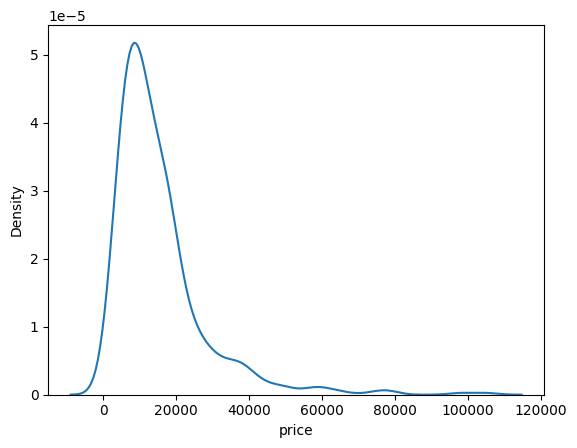

In [190]:
sns.kdeplot(new_df['price'])

/tmp/ipykernel_8414/2904170988.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.histplot(new_df.groupby('company_name')['battery_capacity'].mean())


<Axes: xlabel='battery_capacity', ylabel='Count'>

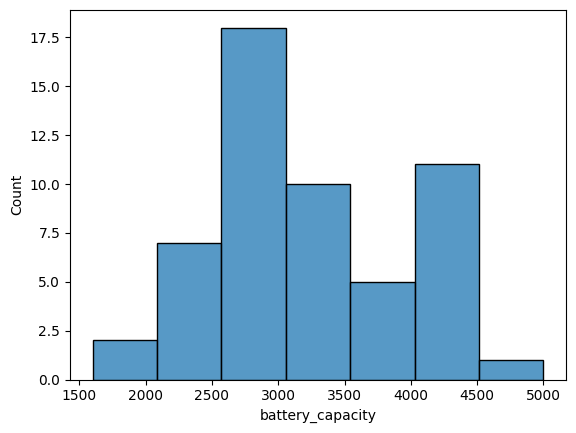

In [199]:
sns.histplot(new_df.groupby('company_name')['battery_capacity'].mean())

<Axes: >

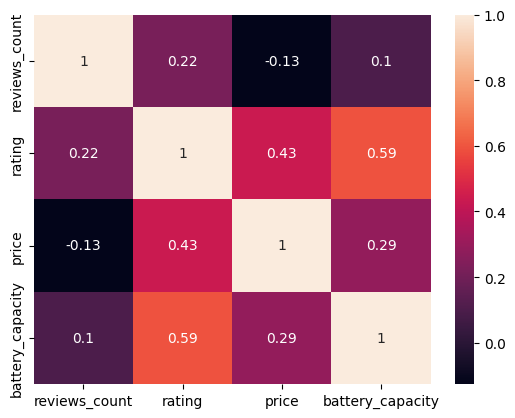

In [193]:
selective_columns = ['reviews_count','rating','price', 'battery_capacity']
sns.heatmap(df[selective_columns].corr(),annot=True)

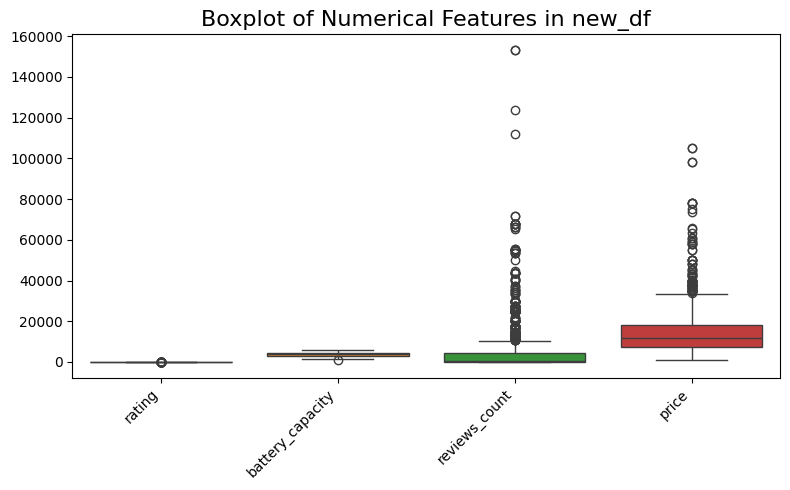

In [204]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=new_df)
plt.title('Boxplot of Numerical Features in new_df', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

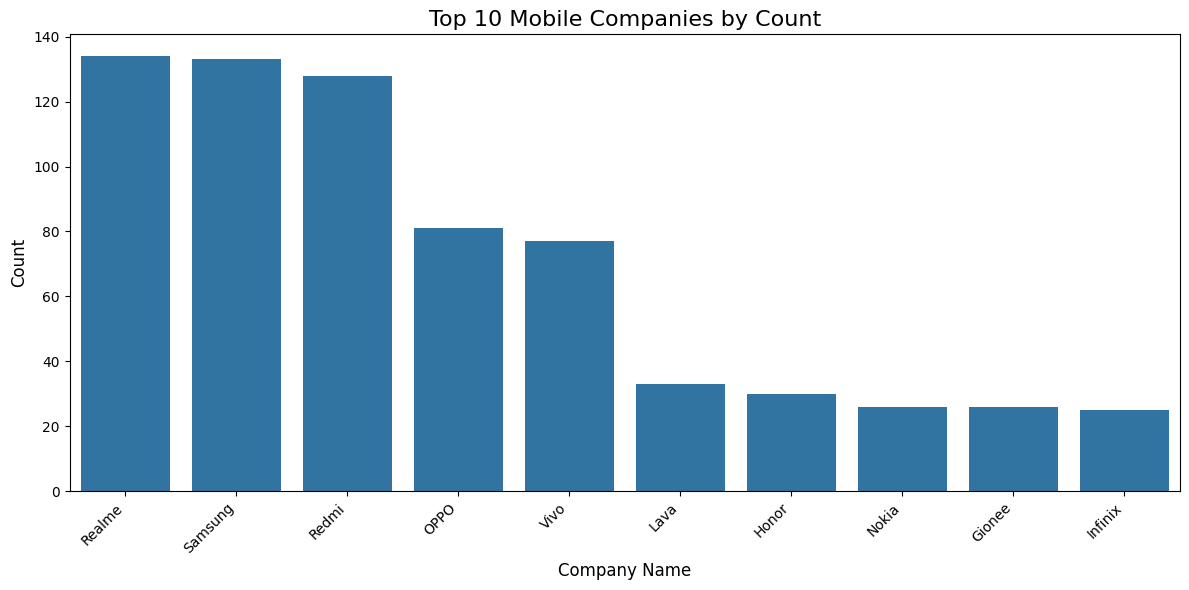

In [211]:
plt.figure(figsize=(12, 6))
sns.countplot(data=new_df, x='company_name', order=new_df['company_name'].value_counts().nlargest(10).index)
plt.title('Top 10 Mobile Companies by Count', fontsize=16)
plt.xlabel('Company Name', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8414/3327500332.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


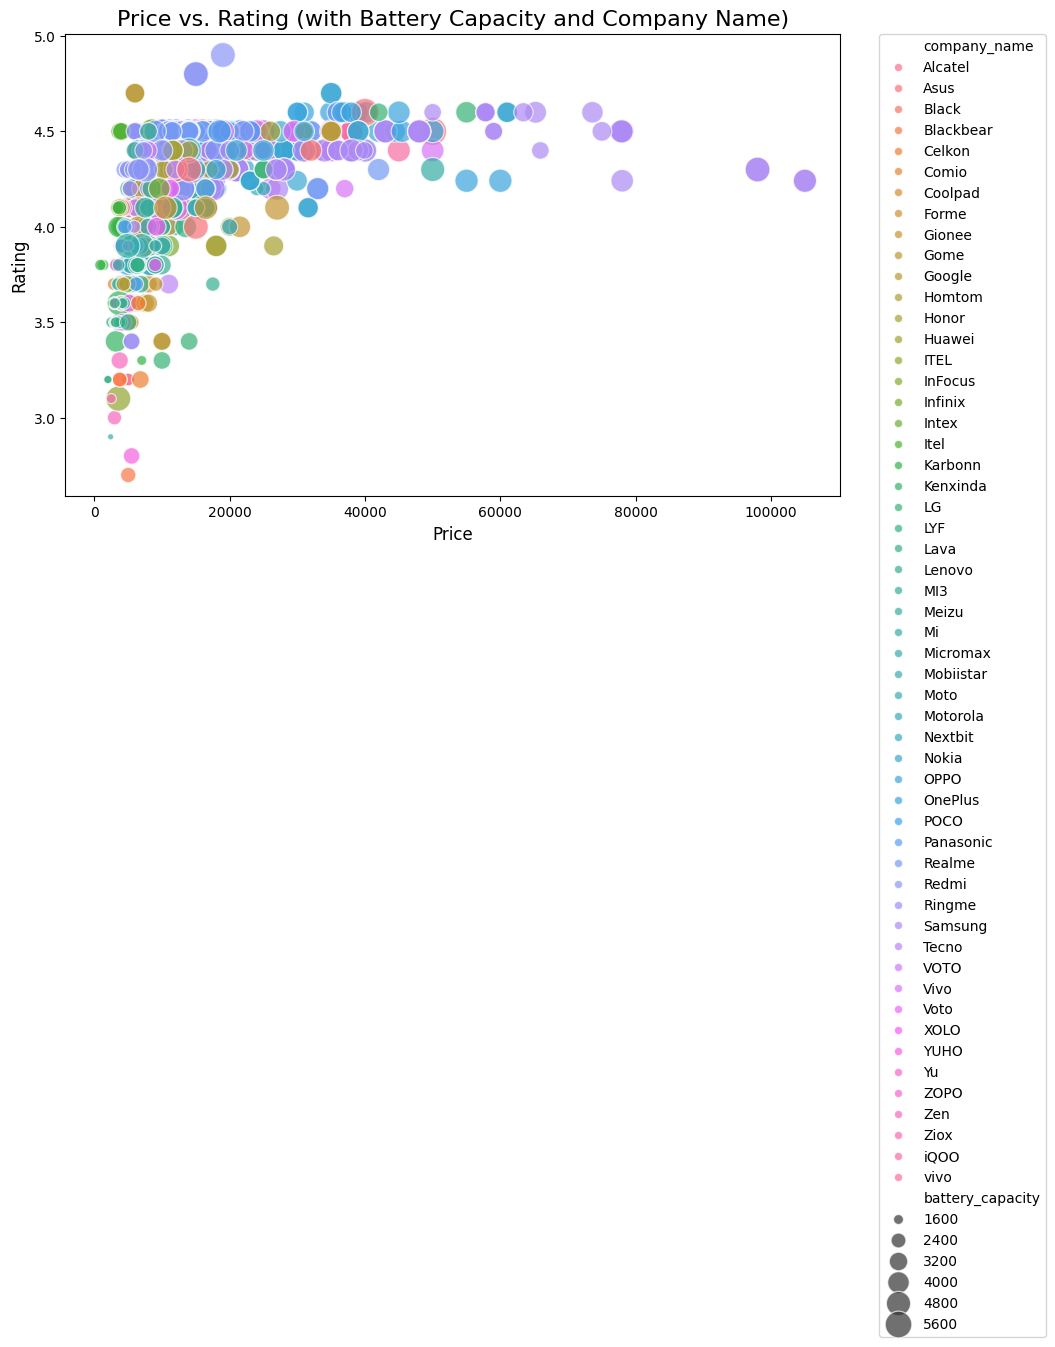

In [212]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=new_df, x='price', y='rating', hue='company_name', size='battery_capacity', sizes=(20, 400), alpha=0.7)
plt.title('Price vs. Rating (with Battery Capacity and Company Name)', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

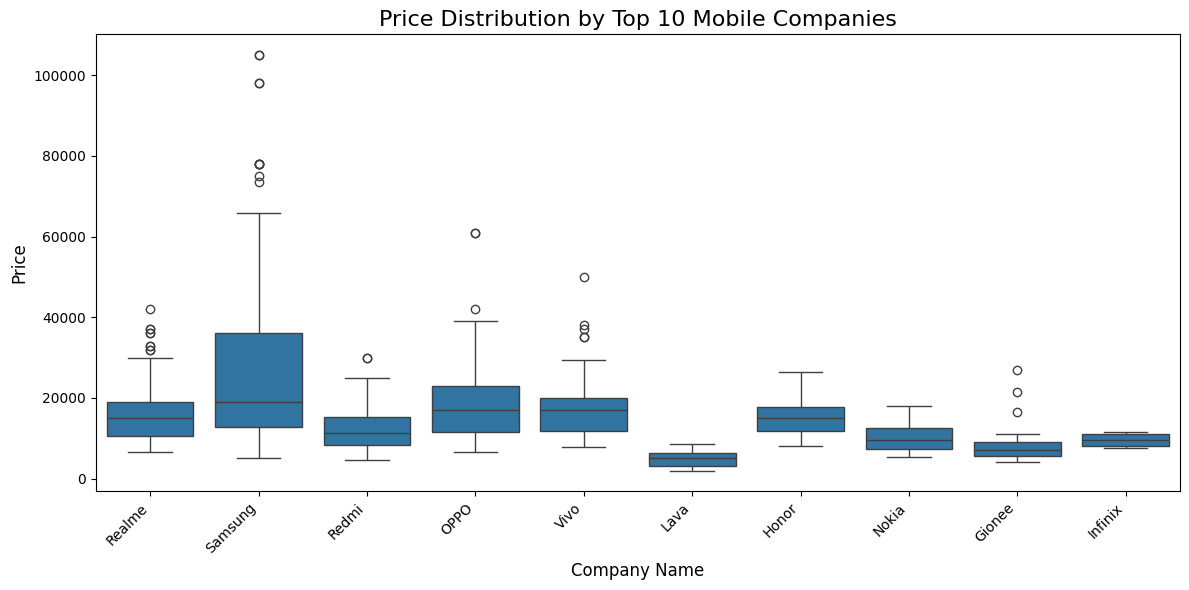

In [213]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=new_df, x='company_name', y='price', order=new_df['company_name'].value_counts().nlargest(10).index)
plt.title('Price Distribution by Top 10 Mobile Companies', fontsize=16)
plt.xlabel('Company Name', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

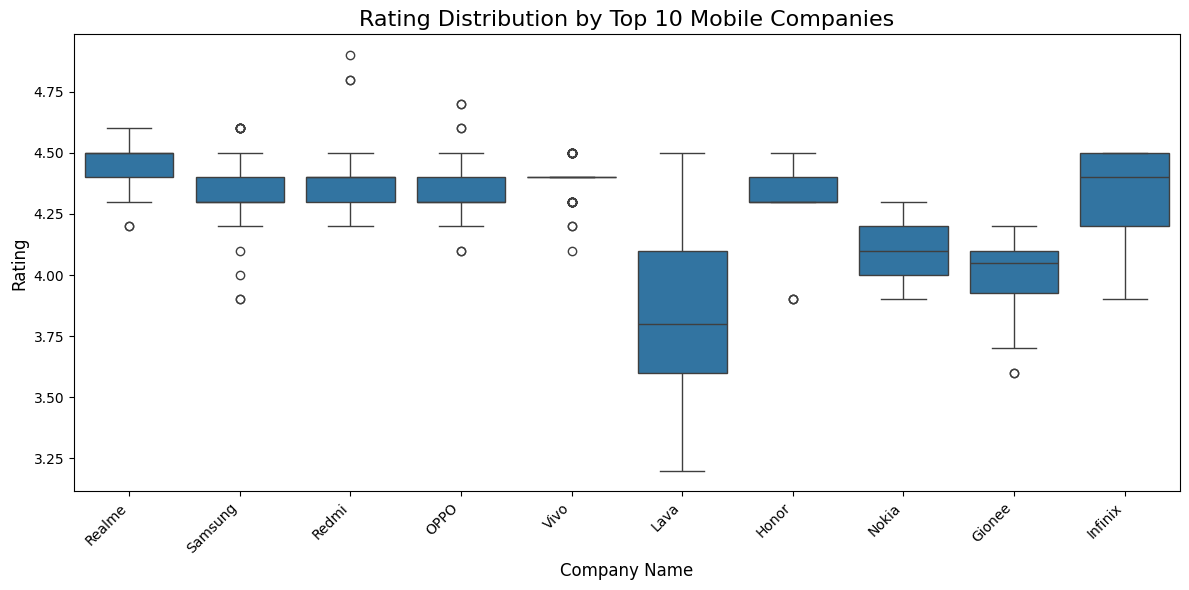

In [214]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=new_df, x='company_name', y='rating', order=new_df['company_name'].value_counts().nlargest(10).index)
plt.title('Rating Distribution by Top 10 Mobile Companies', fontsize=16)
plt.xlabel('Company Name', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary of Analysis

Based on the visualizations, here are some key insights:

*   **Price Distribution:** The KDE plot showed the overall distribution of mobile phone prices, highlighting common price ranges. Most phones are in the lower to mid-price range, with a long tail extending to higher-priced devices.
*   **Correlations:** The heatmap indicated the strength and direction of relationships between `reviews_count`, `rating`, `price`, and `battery_capacity`. For example, it might show if higher prices correlate with higher ratings or larger battery capacities.
*   **Numerical Feature Distributions:** The boxplot provided a quick overview of the central tendency, spread, and outliers for all numerical features in `new_df`, such as price, rating, battery capacity, and reviews count.
*   **Top Mobile Companies:** The countplot clearly identified the top 10 mobile companies by the number of models in the dataset, showcasing their market presence.
*   **Price vs. Rating & Battery Capacity:** The scatter plot helps visualize if there's a relationship between a phone's price and its rating, and how battery capacity plays into this, often differentiated by company.
*   **Company-wise Price and Rating:** The boxplots for 'price' and 'rating' by 'company_name' reveal how different brands position themselves in terms of pricing and perceived quality (ratings) by customers.